## Neutron flux reference and external measurements

The thermal neutron flux at the irradiation position inside the paraffin moderator is taken from the laboratory guide:

$$
\Phi_\mathrm{irr} = 2.3 \cdot 10^4 \ \mathrm{n\,s^{-1}\,cm^{-2}}.
$$

This value applies to the sample position a few cm from the AmBe source inside the paraffin moderator. It is therefore used directly for activation calculations.

The measurements in `neutron_logs_P1`, `neutron_logs_P2`, and `neutron_logs_P3` were performed outside the cabinet/source housing at different positions. These are dose-rate measurements from the AE 2202D neutron dose-rate meter and should not be interpreted as the same flux as the irradiation-position value.

For comparison, the external dose-rate measurements are converted to an approximate thermal-equivalent neutron flux using

$$
\phi = \frac{\dot{H}}{h_\phi},
$$

where $\dot{H}$ is the measured dose rate and $h_\phi$ is an assumed fluence-to-dose coefficient for thermal neutrons.

The result is therefore an external thermal-equivalent flux estimate, not a direct measurement of the flux inside the paraffin.

The source test report gives the total neutron emission of the AmBe source as

$$
S = 1.2 \cdot 10^7 \ \mathrm{n/s}.
$$

This is the total neutron production rate of the source and should not be confused with the neutron flux. The flux depends on position, geometry, moderation, scattering and absorption.

For activation calculations, the relevant value is the local thermal neutron flux at the irradiation position:

$$
\Phi_\mathrm{irr} = 2.3 \cdot 10^4 \ \mathrm{n\,s^{-1}\,cm^{-2}}.
$$

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = "."

LOG_FOLDERS = [
    "neutron_logs_P1",
    "neutron_logs_P2",
    "neutron_logs_P3",
]

# Total neutron emission from the AmBe source test report.
# This is the total number of neutrons emitted by the source per second.
# It is NOT the same as the neutron flux at the irradiation position.
SOURCE_NEUTRON_EMISSION = 1.2e7  # n/s

# Reference thermal neutron flux from the lab guide.
# This applies to the irradiation/sample position inside the paraffin,
# a few cm from the source.
# This is the value used for activation calculations.
PHI_IRRADIATION_THERMAL = 2.3e4  # n / (s cm^2)

# Approximate fluence-to-dose coefficient for thermal neutrons.
# Used only to convert external dose-rate measurements outside the cabinet
# to a thermal-equivalent flux estimate.
H_PHI_THERMAL_pSv_cm2 = 3.0  # pSv cm^2

In [2]:
# ============================================================
# Unit conversions
# ============================================================

def mrem_h_to_uSv_h(mrem_h):
    """
    1 mrem/h = 10 µSv/h
    """
    return 10.0 * mrem_h


def uSv_h_to_Sv_s(uSv_h):
    """
    Convert µSv/h to Sv/s.
    """
    return uSv_h * 1e-6 / 3600.0


def flux_from_dose_rate(uSv_h, H_PHI_pSv_cm2):
    """
    Convert neutron dose rate to approximate neutron flux.

    Parameters
    ----------
    uSv_h : float or array
        Dose rate in µSv/h.

    H_PHI_pSv_cm2 : float
        Fluence-to-dose coefficient in pSv cm^2.

    Returns
    -------
    flux : float or array
        Approximate neutron flux in n/(s cm^2).
    """

    Hdot_Sv_s = uSv_h_to_Sv_s(uSv_h)

    # pSv cm^2 -> Sv cm^2
    H_PHI_Sv_cm2 = H_PHI_pSv_cm2 * 1e-12

    return Hdot_Sv_s / H_PHI_Sv_cm2

In [3]:
# ============================================================
# Filnavn og raw-string parsing
# ============================================================


def parse_position_from_filename(filename):
    """
    Extract P, x and y from filenames like:

        NF_P1_x_0_y_42_10_min.csv
        NF P1 x 0 y 42 10 min.csv
        NF_P2_x_114_y_55_10_min_LONG_mrem.csv
        NF P3 x 0 y 45 10 min 2 mrem.csv
    """

    name = os.path.basename(filename)

    # Remove extension
    name = os.path.splitext(name)[0]

    # Allow both spaces and underscores
    pattern = r"NF[\s_]+(P\d+)[\s_]+x[\s_]+([0-9.]+)[\s_]+y[\s_]+([0-9.]+)"

    match = re.search(pattern, name)

    if match is None:
        print(f"Could not parse position from filename: {name}")
        return None, None, None

    point = match.group(1)
    x_cm = float(match.group(2))
    y_cm = float(match.group(3))

    return point, x_cm, y_cm


def decode_raw_to_mrem_h(raw_string):
    """
    Decode raw strings like:

        J336J40

    Example:
        J336J40 -> hex 36 -> decimal 54
    """

    raw_string = str(raw_string).strip()

    match = re.search(r"J3([0-9A-Fa-f]+)J", raw_string)

    if match is None:
        return np.nan

    hex_part = match.group(1)

    try:
        return int(hex_part, 16)
    except ValueError:
        return np.nan
    
# ============================================================
# CSV reading and processing
# ============================================================

def read_neutron_csv(path):
    """
    Read one neutron log CSV and return a DataFrame with mrem/h.

    Supports both:
    - files already containing 'mrem/h'
    - files containing 'raw', where mrem/h is decoded from strings like J336J40
    """

    df = pd.read_csv(path)

    # Clean column names
    df.columns = [c.strip() for c in df.columns]

    if "mrem/h" in df.columns:
        df["mrem/h"] = pd.to_numeric(df["mrem/h"], errors="coerce")

    elif "raw" in df.columns:
        df["mrem/h"] = df["raw"].apply(decode_raw_to_mrem_h)

    else:
        raise ValueError(f"No 'mrem/h' or 'raw' column found in {path}")

    df = df.dropna(subset=["mrem/h"])

    return df

In [4]:
print("Current working directory:")
print(os.getcwd())
print()

for folder in LOG_FOLDERS:
    folder_path = os.path.join(BASE_DIR, folder)
    files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    print(folder_path)
    print(f"Number of CSV files found: {len(files)}")

    for f in files[:5]:
        print("  ", f)

    print()

Current working directory:
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn

./neutron_logs_P1
Number of CSV files found: 18
   ./neutron_logs_P1/NF_P1_x_0_y_42_10_min.csv
   ./neutron_logs_P1/NF_P1_x_0_y_85_10_min.csv
   ./neutron_logs_P1/NF_P1_x_114_y_42_10_min.csv
   ./neutron_logs_P1/NF_P1_x_114_y_85_10_min.csv
   ./neutron_logs_P1/NF_P1_x_176_y_42_10_min.csv

./neutron_logs_P2
Number of CSV files found: 17
   ./neutron_logs_P2/NF_P2_x_0_y_85_10_min_LONG_mrem.csv
   ./neutron_logs_P2/NF_P2_x_114_y_55_10_min_LONG_mrem.csv
   ./neutron_logs_P2/NF_P2_x_114_y_85_10_min_LONG_mrem.csv
   ./neutron_logs_P2/NF_P2_x_156_y_85_10_min_LONG_mrem.csv
   ./neutron_logs_P2/NF_P2_x_176_y_55_10_min_LONG__mrem.csv

./neutron_logs_P3
Number of CSV files found: 20
   ./neutron_logs_P3/NF_P3_x_0_y_45_10_min_2_mrem.csv
   ./neutron_logs_P3/NF_P3_x_0_y_45_10_min_mrem.csv
   ./neutron_logs_P3/NF_P3_x_0_y_85_10_min_mrem.csv
   ./neutron_logs_P3/NF_P3_x_100_y_85_10_min_mrem.csv
   ./neutron_logs_P3

In [5]:
rows = []
skipped_files = []

for folder in LOG_FOLDERS:
    folder_path = os.path.join(BASE_DIR, folder)
    files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    print(f"Reading folder: {folder_path}")
    print(f"Number of CSV files found: {len(files)}")

    for path in files:
        point, x_cm, y_cm = parse_position_from_filename(path)

        if point is None:
            skipped_files.append(path)
            continue

        try:
            df = read_neutron_csv(path)
        except Exception as e:
            print(f"Could not read file: {path}")
            print(e)
            skipped_files.append(path)
            continue

        if df.empty:
            print(f"File contains no valid mrem/h values: {path}")
            skipped_files.append(path)
            continue

        mrem_vals = df["mrem/h"].to_numpy()

        median_mrem_h = np.median(mrem_vals)
        mean_mrem_h = np.mean(mrem_vals)
        std_mrem_h = np.std(mrem_vals, ddof=1) if len(mrem_vals) > 1 else np.nan
        min_mrem_h = np.min(mrem_vals)
        max_mrem_h = np.max(mrem_vals)
        sum_mrem_h = np.sum(mrem_vals)

        median_uSv_h = mrem_h_to_uSv_h(median_mrem_h)
        mean_uSv_h = mrem_h_to_uSv_h(mean_mrem_h)

        flux_thermal_equiv = flux_from_dose_rate(
            median_uSv_h,
            H_PHI_pSv_cm2=H_PHI_THERMAL_pSv_cm2
        )

        rows.append({
            "file": os.path.basename(path),
            "folder": folder,
            "point": point,
            "x_cm": x_cm,
            "y_cm": y_cm,
            "N": len(df),

            "median_mrem_h": median_mrem_h,
            "mean_mrem_h": mean_mrem_h,
            "std_mrem_h": std_mrem_h,
            "min_mrem_h": min_mrem_h,
            "max_mrem_h": max_mrem_h,
            "sum_mrem_h": sum_mrem_h,

            "median_uSv_h": median_uSv_h,
            "mean_uSv_h": mean_uSv_h,

            "external_flux_thermal_equiv_n_cm2_s": flux_thermal_equiv,
            "thermal_equiv_fraction_of_irradiation_flux": flux_thermal_equiv / PHI_IRRADIATION_THERMAL,
        })

    print()

print(f"Number of files successfully loaded: {len(rows)}")
print(f"Number of skipped files: {len(skipped_files)}")

if skipped_files:
    print()
    print("Skipped files:")
    for f in skipped_files:
        print("  ", f)

Reading folder: ./neutron_logs_P1
Number of CSV files found: 18

Reading folder: ./neutron_logs_P2
Number of CSV files found: 17

Reading folder: ./neutron_logs_P3
Number of CSV files found: 20

Number of files successfully loaded: 55
Number of skipped files: 0


In [14]:
summary = pd.DataFrame(rows)

if summary.empty:
    raise RuntimeError(
        "No data were loaded. Files were found, but no filenames matched the position pattern or no valid mrem/h/raw columns were found."
    )

summary = summary.sort_values(["point", "y_cm", "x_cm"]).reset_index(drop=True)

summary

,file,folder,point,x_cm,y_cm,N,median_mrem_h,mean_mrem_h,std_mrem_h,min_mrem_h,max_mrem_h,sum_mrem_h,median_uSv_h,mean_uSv_h,external_flux_thermal_equiv_n_cm2_s,thermal_equiv_fraction_of_irradiation_flux
0,NF_P1_x_0_y_42_10_min.csv,neutron_logs_P1,P1,0.0,42.0,600,53.0,54.210000,9.212347,24,86,32526,530.0,542.100000,49074.074074,2.133655
1,NF_P1_x_4_y_42_10_min.csv,neutron_logs_P1,P1,4.0,42.0,600,49.0,47.451667,8.806641,21,71,28471,490.0,474.516667,45370.370370,1.972625
2,NF_P1_x_4_y_42_10_min_SHORT.csv,neutron_logs_P1,P1,4.0,42.0,600,49.0,46.745000,9.015104,22,72,28047,490.0,467.450000,45370.370370,1.972625
3,NF_P1_x_57_y_42_10_min.csv,neutron_logs_P1,P1,57.0,42.0,600,7.0,8.673333,4.773321,0,22,5204,70.0,86.733333,6481.481481,0.281804
4,NF_P1_x_114_y_42_10_min.csv,neutron_logs_P1,P1,114.0,42.0,601,3.0,3.028286,1.722653,0,9,1820,30.0,30.282862,2777.777778,0.120773
5,NF_P1_x_176_y_42_10_min.csv,neutron_logs_P1,P1,176.0,42.0,601,2.0,1.795341,1.297322,0,7,1079,20.0,17.953411,1851.851852,0.080515
6,NF_P1_x_199_y_42_10_min.csv,neutron_logs_P1,P1,199.0,42.0,600,1.0,1.396667,1.252439,0,7,838,10.0,13.966667,925.925926,0.040258
7,NF_P1_x_320_y_42_10_min.csv,neutron_logs_P1,P1,320.0,42.0,600,0.0,0.475000,0.711960,0,4,285,0.0,4.750000,0.000000,0.000000
8,NF_P1_x_420_y_42_10_min.csv,neutron_logs_P1,P1,420.0,42.0,600,0.0,0.215000,0.475203,0,3,129,0.0,2.150000,0.000000,0.000000
9,NF_P1_x_0_y_85_10_min.csv,neutron_logs_P1,P1,0.0,85.0,601,7.0,7.918469,4.519772,1,23,4759,70.0,79.184692,6481.481481,0.281804


#### Gemmer resultattabellen:

In [15]:
out_path = os.path.join(BASE_DIR, "external_neutron_dose_and_flux_summary.csv")
summary.to_csv(out_path, index=False)

print(f"Saved summary to: {out_path}")

Saved summary to: ./external_neutron_dose_and_flux_summary.csv


#### Reference-fluxen:

Reference thermal neutron flux from lab guide:
Phi_irradiation = 2.300e+04 n/(s cm^2)

This value applies to the irradiation/sample position inside the paraffin.
It should be used directly for activation calculations.

External measurements are converted only to approximate thermal-equivalent flux.
Used fluence-to-dose coefficient: 3.00 pSv cm^2

#### Plot ekstern dosisrate vs. avstand fra kilden:

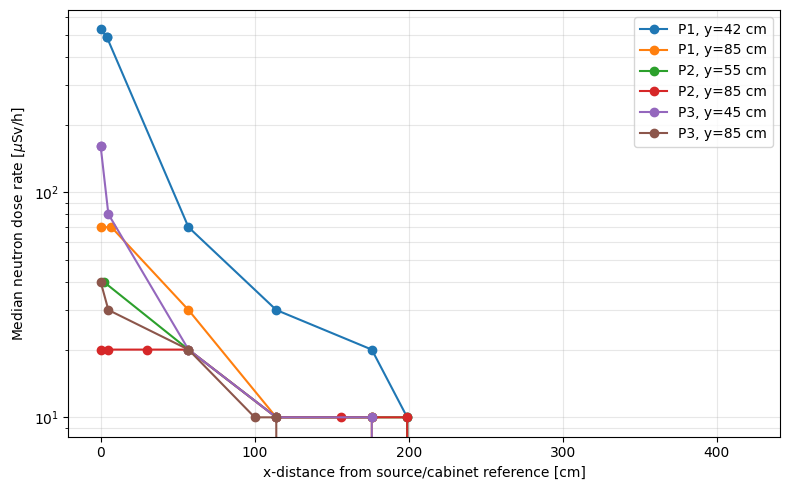

In [16]:
plt.figure(figsize=(8, 5))

for (point, y_cm), group in summary.groupby(["point", "y_cm"]):
    group = group.sort_values("x_cm")

    plt.plot(
        group["x_cm"],
        group["median_uSv_h"],
        "o-",
        label=f"{point}, y={y_cm:.0f} cm"
    )

plt.xlabel("x-distance from source/cabinet reference [cm]")
plt.ylabel(r"Median neutron dose rate [$\mu$Sv/h]")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Plot ekstern termisk-ækvivalent flux:

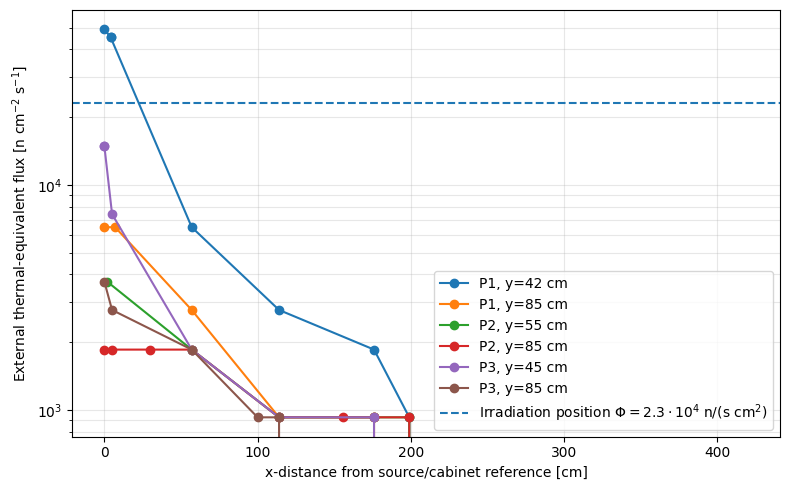

In [17]:
plt.figure(figsize=(8, 5))

for (point, y_cm), group in summary.groupby(["point", "y_cm"]):
    group = group.sort_values("x_cm")

    plt.plot(
        group["x_cm"],
        group["external_flux_thermal_equiv_n_cm2_s"],
        "o-",
        label=f"{point}, y={y_cm:.0f} cm"
    )

plt.axhline(
    PHI_IRRADIATION_THERMAL,
    linestyle="--",
    label=r"Irradiation position $\Phi = 2.3 \cdot 10^4$ n/(s cm$^2$)"
)

plt.xlabel("x-distance from source/cabinet reference [cm]")
plt.ylabel(r"External thermal-equivalent flux [n cm$^{-2}$ s$^{-1}$]")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Flux til aktiveringsberegninger:

In [18]:
# Thermal flux at the irradiation/sample position inside the paraffin
phi = PHI_IRRADIATION_THERMAL

print(f"Flux used for activation calculations: {phi:.3e} n/(s cm^2)")

Flux used for activation calculations: 2.300e+04 n/(s cm^2)


In [6]:
print("AmBe neutron source:")
print(f"Total neutron emission = {SOURCE_NEUTRON_EMISSION:.3e} n/s")
print()

print("Reference thermal neutron flux from lab guide:")
print(f"Phi_irradiation = {PHI_IRRADIATION_THERMAL:.3e} n/(s cm^2)")
print()

print("Important distinction:")
print("SOURCE_NEUTRON_EMISSION is the total neutron production of the source.")
print("PHI_IRRADIATION_THERMAL is the local thermal neutron flux at the sample position.")
print()

print("For activation calculations, use:")
print(f"phi = {PHI_IRRADIATION_THERMAL:.3e} n/(s cm^2)")
print()

print("External measurements are converted only to approximate thermal-equivalent flux.")
print(f"Used fluence-to-dose coefficient: {H_PHI_THERMAL_pSv_cm2:.2f} pSv cm^2")

AmBe neutron source:
Total neutron emission = 1.200e+07 n/s

Reference thermal neutron flux from lab guide:
Phi_irradiation = 2.300e+04 n/(s cm^2)

Important distinction:
SOURCE_NEUTRON_EMISSION is the total neutron production of the source.
PHI_IRRADIATION_THERMAL is the local thermal neutron flux at the sample position.

For activation calculations, use:
phi = 2.300e+04 n/(s cm^2)

External measurements are converted only to approximate thermal-equivalent flux.
Used fluence-to-dose coefficient: 3.00 pSv cm^2
